Video fps: 25.00 → sampling every 8 frames

0: 384x640 6 persons, 1 bottle, 2 cups, 1 chair, 1 dining table, 2 laptops, 50.5ms
Speed: 2.0ms preprocess, 50.5ms inference, 7.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 1 bottle, 3 cups, 1 chair, 1 dining table, 1 laptop, 27.1ms
Speed: 1.5ms preprocess, 27.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 1 bottle, 2 cups, 1 chair, 1 dining table, 1 laptop, 28.7ms
Speed: 1.3ms preprocess, 28.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 1 bottle, 3 cups, 2 chairs, 1 dining table, 1 laptop, 28.8ms
Speed: 1.4ms preprocess, 28.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 1 bottle, 3 cups, 1 chair, 1 dining table, 1 laptop, 30.1ms
Speed: 1.5ms preprocess, 30.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 1 bottle, 3 cups, 1 chair, 1 din

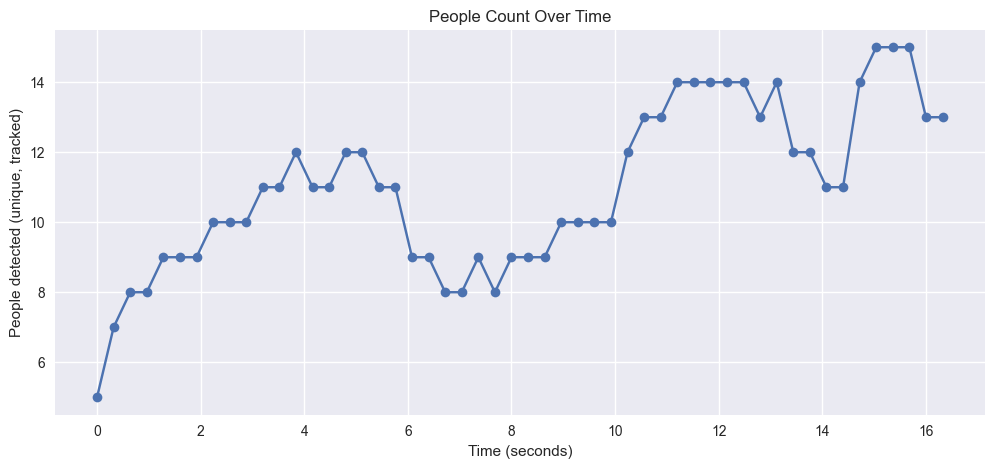

Visualization saved in: /Users/arif/Desktop/crowddetectionai/visualization/graphs/count_forecast_v3_5.png


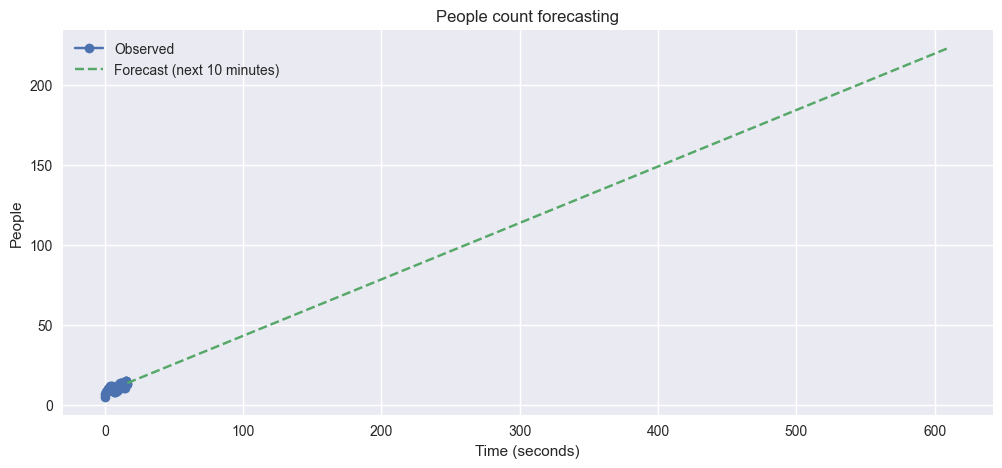

,time_s,predicted_people
0,16.32,13.857765
1,21.32,15.620630
2,26.32,17.383495
3,31.32,19.146360
4,36.32,20.909225
...,...,...
115,591.32,216.587237
116,596.32,218.350102
117,601.32,220.112967
118,606.32,221.875832


In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression

plt.style.use("seaborn-v0_8")

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# simple sort-like tracker

class Track:
    def __init__(self, track_id, bbox):
        self.id = track_id
        self.bbox = bbox
        self.missed = 0  # how many frames skipped


def iou(bb1, bb2):
    x1 = max(bb1[0], bb2[0])
    y1 = max(bb1[1], bb2[1])
    x2 = min(bb1[2], bb2[2])
    y2 = min(bb1[3], bb2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (bb1[2] - bb1[0]) * (bb1[3] - bb1[1])
    area2 = (bb2[2] - bb2[0]) * (bb2[3] - bb2[1])

    return inter / (area1 + area2 - inter + 1e-6)


def update_tracks(tracks, detections, iou_threshold=0.3):
    assigned = set()

    for det in detections:
        best_iou = 0
        best_track = None

        for track in tracks:
            val = iou(det, track.bbox)
            if val > best_iou:
                best_iou = val
                best_track = track

        if best_iou > iou_threshold and best_track not in assigned:
            best_track.bbox = det
            best_track.missed = 0
            assigned.add(best_track)
        else:
            tracks.append(Track(len(tracks) + 1, det))

    # removing dead tracks
    new_tracks = []
    for t in tracks:
        if t not in assigned:
            t.missed += 1
        if t.missed < 10:  # keep track alive for 10 missed frames
            new_tracks.append(t)

    return new_tracks

VIDEO_PATH = "../data/video/office1.mp4"
OUTPUT_DIR = Path("..data/outputs/outputsv3.5")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR = Path("../visualization/graphs")

TARGET_FPS = 3   # fps

cap = cv2.VideoCapture(VIDEO_PATH)
source_fps = cap.get(cv2.CAP_PROP_FPS)
frame_interval = int(source_fps / TARGET_FPS)

print(f"Video fps: {source_fps:.2f} → sampling every {frame_interval} frames")

frame_index = 0
saved_index = 0

records = []
tracks = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_index % frame_interval != 0:
        frame_index += 1
        continue

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # yolo detection
    result = model.predict(frame_rgb, imgsz=640, conf=0.25)
    boxes = result[0].boxes.xyxy.cpu().numpy()
    classes = result[0].boxes.cls.cpu().numpy().astype(int)

    # keep only persons
    person_boxes = [boxes[i] for i, c in enumerate(classes) if c == 0]

    # update tracking
    tracks = update_tracks(tracks, person_boxes)

    # count unique tracked individuals
    people_count = len(tracks)

    # draw boxes
    annotated = frame_rgb.copy()
    for track in tracks:
        x1, y1, x2, y2 = map(int, track.bbox)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(annotated, f"ID {track.id}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    # save frame
    out_path = OUTPUT_DIR / f"frame_{saved_index:04d}.jpg"
    cv2.imwrite(str(out_path), cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

    # save record
    timestamp = frame_index / source_fps
    records.append({"time_s": timestamp, "people": people_count})

    frame_index += 1
    saved_index += 1

cap.release()

df = pd.DataFrame(records)
df.head()

plt.figure(figsize=(12,5))
plt.plot(df["time_s"], df["people"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("People detected (unique, tracked)")
plt.title("People Count Over Time")
plt.grid(True)
plt.show()

# linear regression forecasting
X = df["time_s"].values.reshape(-1, 1)
y = df["people"].values

model_lr = LinearRegression()
model_lr.fit(X, y)

# predict next 10 minutes (600 seconds)
future_times = np.arange(df["time_s"].max(), df["time_s"].max() + 600, 5)
future_preds = model_lr.predict(future_times.reshape(-1, 1))

df_forecast = pd.DataFrame({
    "time_s": future_times,
    "predicted_people": future_preds
})

df_forecast.head()

plt.figure(figsize=(12,5))
plt.plot(df["time_s"], df["people"], label="Observed", marker="o")
plt.plot(future_times, future_preds, '--', label="Forecast (next 10 minutes)")
plt.xlabel("Time (seconds)")
plt.ylabel("People")
plt.title("People count forecasting")
plt.grid(True)
plt.legend()

visual_path = VIS_DIR / "count_forecast_v3_5.png"
plt.savefig(visual_path, bbox_inches="tight")
print(f"Visualization saved in: {visual_path.resolve()}")
plt.show()

df_forecast